In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, END, START
from langgraph.graph.message import add_messages
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.messages import BaseMessage

In [2]:
from typing import List, Dict, Any, Literal
from typing_extensions import Annotated, TypedDict
from langgraph.graph import MessagesState
from langgraph.types import Command
from langchain_core.language_models.chat_models import BaseChatModel
from langchain_core.messages import SystemMessage, HumanMessage , AIMessage

from backend.chatbot.prompts.router.supervisor_prompt import prompt as supervisor_prompt

def merge_dicts(old, new): # i used this to let collected output gest updated before overwriting
    return {**old, **new}

class GraphState(MessagesState):
    remaining_agents: List[str]
    collected_outputs: Annotated[Dict[str, Any], merge_dicts]
    final_answer: str


class RouterState(TypedDict):
    next: str
    reason: str
    confidence: float

agents_description = """
        attachment: Detects attachment style patterns (secure/anxious/avoidant/disorganized) from relational signals.
        clinical_disorder: Detects possible clinical syndrome patterns from symptom clusters.
        cognetive_distortion: Detects distorted thinking patterns (catastrophizing, black-and-white thinking, etc.).
        functional_level: Assesses impairment in work, social, self-care, and daily functioning.
        personal_traits: Detects stable personality trait tendencies from repeated behavioral-emotional patterns.
        relational_pattern: Detects interpersonal dynamics, boundaries, dependency, conflict, and communication patterns.
        schema: Detects early maladaptive schemas and core beliefs.
""".strip()


In [3]:
import os
from langchain_openai import ChatOpenAI
from user_context import first, second, third


# llm = ChatOpenAI(
#     model="deepseek-v4-flash",
#     api_key='sk-1666caf6a268456d8df5b5da9853d5d6',
#     base_url="https://api.deepseek.com",
#     temperature=0,
#     reasoning_effort="high",
#     extra_body={"thinking": {"type": "enabled"}}
# )

llm = ChatOpenAI(
    model="deepseek-v4-flash",
    api_key="sk-1666caf6a268456d8df5b5da9853d5d6",
    base_url="https://api.deepseek.com",
    temperature=0,
    reasoning_effort="high",
    extra_body={
        "thinking": {"type": "enabled"},
        # "response_format": {"type": "json_object"} 
    }
)

# from langchain_openai import ChatOpenAI

# llm = ChatOpenAI(
#     base_url="https://api.gapgpt.app/v1",
#     api_key="sk-maGdVnAynciq7MyrhlnX6NrVYcPirPgNR1y8N5CcxglcEVWG",
#     model="gpt-5.4",
#     temperature=0
# )

In [ ]:
llm.invoke('سلام')

### agent list

In [4]:

from backend.chatbot.prompts.attachment import prompt as attachment_prompt
from backend.chatbot.prompts.schema import prompt as  schema_prompt 
from backend.chatbot.prompts.clinical_disorder import prompt as clinical_disorder_prompt 
from backend.chatbot.prompts.personal_traits import prompt as personal_train_prompt 
from backend.chatbot.prompts.relational_pattern import prompt as relational_pattern_prompt
from backend.chatbot.prompts.functional_level import prompt as functional_level_prompt
from backend.chatbot.prompts.cognetive_distortion import prompt as cognitive_distortation_prompt
import json

def create_agent_node(llm  , prompt , node_name) :
    
    def agent(state:GraphState)-> Command[Literal['supervisor']]: 
        user_context = state["messages"][-1].content + " "
        messages = [
            SystemMessage(content= prompt), 
            HumanMessage(content = user_context)
        ]

        response = llm.invoke(messages)
        print(response.response_metadata['token_usage'])

        # updated_messages = state['messages'] + [
        #     AIMessage(content = response.content , name = node_name)
        # ]
        try: 
            data = json.loads(response.content)
            print('-'*50)
            print(f'agent {node_name} called , response is :',data)
            print(f'agent {node_name}')

            print('-'*50)
        except: 
            print('json error raw output is ' , response.content)

        return Command(
            update={
                "collected_outputs": {
                    node_name: data
                }
            },
            goto="supervisor"
        )
    return agent

attachment_agent = create_agent_node(llm, attachment_prompt , node_name = 'atthchment')
schema_agent = create_agent_node(llm, schema_prompt , node_name = 'schema')
clinical_disorder_agent = create_agent_node(llm, clinical_disorder_prompt , node_name = 'clinical_disorder')
personal_trait_agent = create_agent_node(llm, personal_train_prompt , node_name = 'personal_trait')
relational_pattern_agent = create_agent_node(llm, relational_pattern_prompt , node_name = 'relational_pattern')
functional_level_agent = create_agent_node(llm, functional_level_prompt , node_name = 'functional_level')
cognitive_distortion_agent = create_agent_node(llm, cognitive_distortation_prompt , node_name = 'cognitive_distortion')

# from tenacity import retry, stop_after_attempt, wait_exponential

# @retry(stop=stop_after_attempt(3), wait=wait_exponential(multiplier=1, min=2, max=10))
# def safe_llm_invoke(prompt):
#     return llm.invoke(prompt)

(با ورودی ~1850 و خروجی ~400)


### planner and executor code 

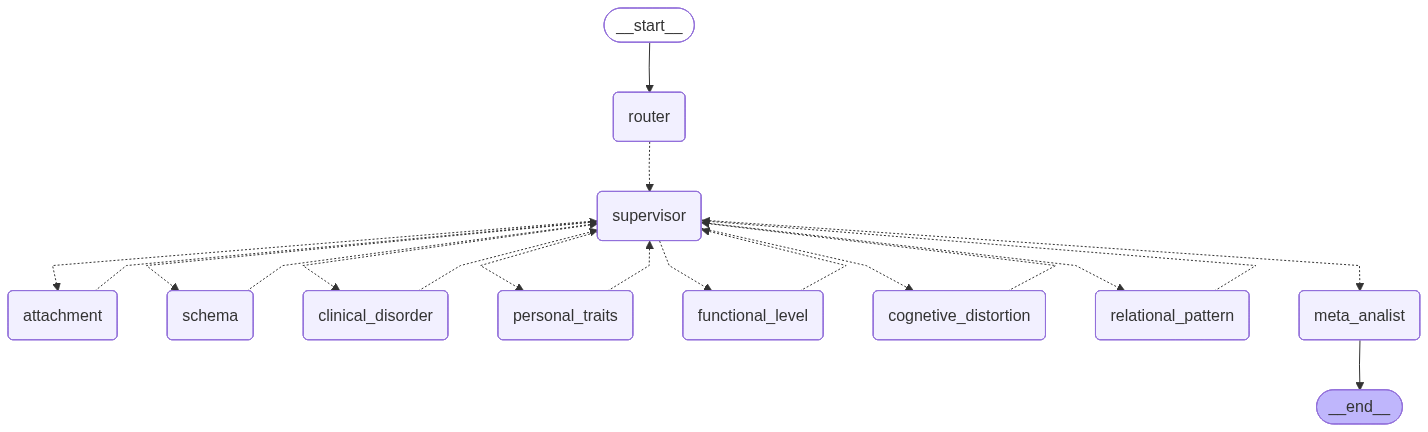

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	router(router)
	supervisor(supervisor)
	attachment(attachment)
	schema(schema)
	clinical_disorder(clinical_disorder)
	personal_traits(personal_traits)
	functional_level(functional_level)
	cognetive_distortion(cognetive_distortion)
	relational_pattern(relational_pattern)
	meta_analist(meta_analist)
	__end__([<p>__end__</p>]):::last
	__start__ --> router;
	attachment -.-> supervisor;
	clinical_disorder -.-> supervisor;
	cognetive_distortion -.-> supervisor;
	functional_level -.-> supervisor;
	personal_traits -.-> supervisor;
	relational_pattern -.-> supervisor;
	router -.-> supervisor;
	schema -.-> supervisor;
	supervisor -.-> attachment;
	supervisor -.-> clinical_disorder;
	supervisor -.-> cognetive_distortion;
	supervisor -.-> functional_level;
	supervisor -.-> meta_analist;
	supervisor -.-> personal_traits;
	supervisor -.-> relational_pattern;
	supervisor -.-> schema;
	meta_analist --> __e

In [5]:
from typing import List, Dict, Any
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, END
from langgraph.types import Command
from langgraph.graph import MessagesState
from backend.chatbot.prompts.meta_analist import prompt as meta_analist_prompt
from user_context import first, second, third
import json

def router_node(state: GraphState) -> Command[
       Literal['supervisor']
    ]:
        remaining_agents = state.get("remaining_agents", [])
        if not remaining_agents:
            return Command(goto="meta_analist")

        options = remaining_agents 

        system_prompt = (
              supervisor_prompt
              + "\n\nAvailable agents: " + ", ".join(options)
              + "\n\nAgent descriptions:\n" + agents_description
            )
        user_context = state["messages"][-1].content

        messages = [
            SystemMessage(content=system_prompt),
            HumanMessage(content=user_context),
        ]

        response = llm.invoke(messages)
        # print(response.response_metadata['token_usage'])

        data = json.loads(response.content)
        print('*'*50)
        print(f'rounter node is called' , data)
        print('*'*50)
        return Command(
            goto = 'supervisor',
            update = {
                'remaining_agents' : data['selected_agents'],
                'collected_outputs': {} 
            }
        )


def supervisor_node(state: GraphState) -> Command[
    Literal[
        "attachment",
        "schema",
        "clinical_disorder",
        "personal_traits",
        "functional_level",
        "cognetive_distortion",
        "relational_pattern",
        "meta_analist", ]
        ]:
    remaining_agents = state.get("remaining_agents", [])

    if not remaining_agents:
        return Command(goto="meta_analist")

    next_agent = remaining_agents[0]
    # print('/'*50)
    # print(f'supervisor node is called , next_agent is' , next_agent)
    # print('/'*50)
    return Command(
        goto=next_agent,
        update={
            "remaining_agents": remaining_agents[1:],
            # 'remaining_agents' : []  
        },
    )

def meta_analist_node(state: GraphState) -> Command:
    outputs = state.get("collected_outputs", {})
    messages = [
    SystemMessage(content=meta_analist_prompt),
    HumanMessage(content=json.dumps(outputs))
        ]
    response = llm.invoke(messages)
    try: 
        result = json.loads(response.content)
    except: 
        print('error happening , raw data ', response.content)

    return Command(
        goto=END,
        update={"final_answer": result},
    )


builder = StateGraph(GraphState)

builder.add_node("router", router_node)
builder.add_node("supervisor", supervisor_node)

agent_info = {
    "attachment" : attachment_prompt,
    "schema" : schema_prompt,
    "clinical_disorder" : clinical_disorder_prompt,
    "personal_traits" : personal_train_prompt,
    "functional_level" : functional_level_prompt,
    'cognetive_distortion' : cognitive_distortation_prompt,
    'relational_pattern' : relational_pattern_prompt
}

for name , prompt in agent_info.items():
    builder.add_node(name, create_agent_node(llm, prompt , node_name = name))

builder.add_node("meta_analist", meta_analist_node)

builder.set_entry_point("router")

graph = builder.compile()

# result = graph.invoke(
#     {
#         "messages": [],
#     }
# )

from IPython.display import Image, display

img = graph.get_graph().draw_mermaid_png()
display(Image(img))
print(graph.get_graph().draw_mermaid())

In [6]:
from backend.chatbot.prompts import emotional_state, personal_traits
from user_context import first

state = {
    "messages": [
        HumanMessage(content=first) 
    ],
    "remaining_agents": [
        "schema",
        "attachment",
        "clinical_disorder",
        "cognetive_distortion",
        "functional_level",
        "personal_traits",
        "relational_pattern",
    ],
    "collected_outputs": {},
    "final_answer": None,  
}

result  = graph.invoke(state)
result

# result = schema_agent(state)

**************************************************
rounter node is called {'selected_agents': ['schema', 'attachment', 'cognetive_distortion', 'functional_level', 'relational_pattern'], 'dropped_agents': ['clinical_disorder', 'personal_traits'], 'routing_rationale': {'schema': 'Client expresses core beliefs of being morally flawed and needing to prove worth, indicating early maladaptive schemas like defectiveness/shame.', 'attachment': 'Client describes cyclical relationship with push-pull dynamics, intense fear of intimacy, and lack of security, showing anxious or disorganized attachment.', 'cognetive_distortion': "Client uses black-and-white thinking ('آدم بدی نیستم' vs 'هیچ تعهد اخلاقی نداره') and catastrophizes about the relationship's impact.", 'functional_level': 'Client reports severe impairment in self-care (not showering for a week), minimal activity, and difficulty functioning in daily life.', 'relational_pattern': 'Client explicitly describes repeated conflict cycles, bounda

{'messages': [HumanMessage(content='\nسلام \nدیشب که توی بغلش بودم بوی گردنش یک لحظه من و یاد ماهان انداخت \nاحساس گناه و عذاب وجدان شدیدی داشتم و دارم \nچرا من باید با بوی گردن اون توی اون لحظه یاد یه نفر دیگه بیوفتم \nچه مشکلی دارم من ؟ \nنکنه واقعا آدمیم که هیچ تعهد اخلاقی نداره ؟ \nامروز زنگ زد بهم \nبه یک بهونه بیخود \nبهش گفتم چرا زنگ زدی ؟ گفت میخوام نشون بدم پایان دنیا نیست تموم شدن رابطه \nنمیخوام برات به صورت یک تروما تموم بشه \nبهش گفتم هربار میبینمت\nهر بار زنگ میزنی \nهر بار پیام میدی \nمن بر میگردم اول چرخه \nبهم زنگ نزن \nپیام نده \nنمیخوام ببینمت \nنمیخوام برگردم توی اون چرخه تکراری \nداشتیم حرف میزدیم \nگفت من الان و نمیگم اون موقع قبل و از عید و میگم \nبهش گفتم تو دنبال یه نکته برای تحقیر و توهین من میگردی این نکته رو بهت نمیدم \nچون لایق این نیستم انقدر بخوای تحقیرم کنی یا توهین کنی یا تهمت بزنی \nباهام در ارتباط نباش \nکاری نداری ؟ گفت از اول نداشتم میخواستم یه هدیه بهت بدم که مادی نیست میتونه معنوی باشه که ایده یه شغل بود \nگفتم مرسی ولی این ایده (از حیوونا توی خون

In [ ]:
result

In [ ]:
result.update['collected_outputs']['schema']['scores']


In [ ]:
summary = result.update['collected_outputs']['schema']['summary']
print(summary)

In [ ]:
result.update['collected_outputs']['schema']['evidence']

In [ ]:
result['collected_outputs'].keys()

options we have 

first -> summorize and run agents 
second -> use one agent for all agents no route and graph 
